In [1]:
from langchain_openrouter import ChatOpenRouter
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters  import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, AnyMessage, AIMessage
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

c:\ML-DL\AgenticAI-LangGraph\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\OMEN\AppData\Local\Temp\ipykernel_19944\3129859803.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [2]:
load_dotenv()

True

In [3]:
subgraph_llm = ChatOpenRouter(
    model="openai/gpt-oss-20b:free",
    temperature=0
)

In [4]:
class SubState(TypedDict):
    input_text: str
    translated_text: str

In [5]:
def translate_text(state: SubState):
    prompt=f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text: {state['input_text']}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content
    return {"translated_text": translated_text}

In [6]:
subgraph_builder = StateGraph(SubState)
subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph=subgraph_builder.compile()

In [7]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_hin: str

In [8]:
parent_llm = ChatOpenRouter(
    model="openai/gpt-oss-20b:free",
    temperature=0
)

In [9]:
def generate_answer(state: ParentState):
    answer=parent_llm.invoke(f"You are an helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {"answer_eng": answer}

In [10]:
def translate_answer(state: ParentState):
    result = subgraph.invoke({"input_text": state['answer_eng']})
    return {"answer_hin": result['translated_text']}

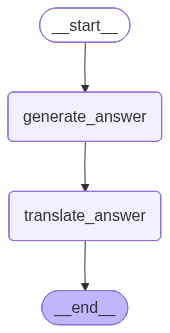

In [11]:
parent_builder = StateGraph(ParentState)
parent_builder.add_node('generate_answer', generate_answer)
parent_builder.add_node('translate_answer', translate_answer)

parent_builder.add_edge(START, 'generate_answer')
parent_builder.add_edge('generate_answer', 'translate_answer')
parent_builder.add_edge('translate_answer', END)

graph = parent_builder.compile()
graph

In [14]:
graph.invoke({'question': "What is Artificial Intelligence?"})

{'question': 'What is Artificial Intelligence?',
 'answer_eng': '**Artificial Intelligence (AI)** is a field of computer science that focuses on creating systems or machines that can perform tasks that normally require human intelligence. These tasks include:\n\n| Task | Typical Human Skill | AI Approach |\n|------|---------------------|-------------|\n| Recognizing speech | Listening & interpreting | Speech‑to‑text models |\n| Understanding language | Reading & comprehension | Natural‑language processing |\n| Seeing objects | Visual perception | Computer vision |\n| Making decisions | Reasoning & judgment | Machine learning, rule‑based systems |\n| Learning from experience | Adaptation | Reinforcement learning, deep learning |\n\n### Core ideas\n\n1. **Representation** – How information is encoded (e.g., numbers, graphs, neural networks).  \n2. **Reasoning** – Drawing conclusions or making predictions from data.  \n3. **Learning** – Improving performance over time by adjusting interna